In [1]:
# Generated By Qiskit Code Assistant
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram,plot_bloch_vector
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager 
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
# Initialize the Qiskit Runtime Service

from test_utils import read_account_file
account = read_account_file('account_info.conf') 
# Ensure the account file is read correctly
print("Account details:", account)

service = QiskitRuntimeService(channel="ibm_cloud",instance=account["instance"],token=account["token"])
backend = service.least_busy()
print(f"Using backend: {backend.name}")

Account details: {'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/ba962309ce1047b196c3c050588a6d71:8fda7a93-e60c-4a4c-ba5b-6d1e5262669c::', 'token': '5iN_CtEVi_QxhMiBnsbIacmxY57F5y4iCzhbaatYPE_A'}
Using backend: ibm_brisbane


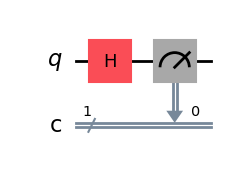

In [ ]:
# Create a quantum circuit for entanglement and measurement then draw it
qc = QuantumCircuit(2, 2)
qc.h(0)  # Apply Hadamard gate to qubit 0
qc.cx(0, 1)  # Apply CNOT gate to entangle qubit 0 and qubit 1
qc.measure([0, 1], [0, 1])  # Measure both qubits
qc.draw("mpl")

In [5]:
# Transpile the circuit using a preset pass manager
pm = generate_preset_pass_manager(backend)
# transpile the circuit
transpiled_circuit = pm.run(qc)
# Create a sampler instance
sampler = Sampler(mode=backend)
# Sample the transpiled circuit
job = sampler.run([transpiled_circuit], shots=1024)
print(f"Job ID: {job.job_id()}")

Job ID: d2b1echncmis73a1a40g


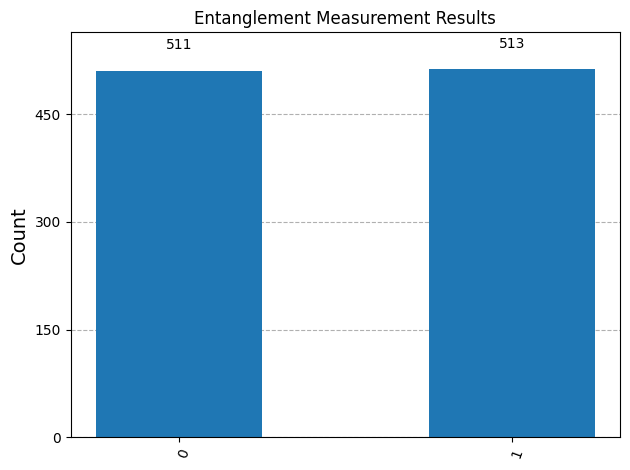

In [11]:
# Get the results
results = job.result()
# Plot the histogram of results using cregisters
counts = results[0].data.c.get_counts()
# Plot the histogram
plot_histogram(counts, title="Entanglement Measurement Results")

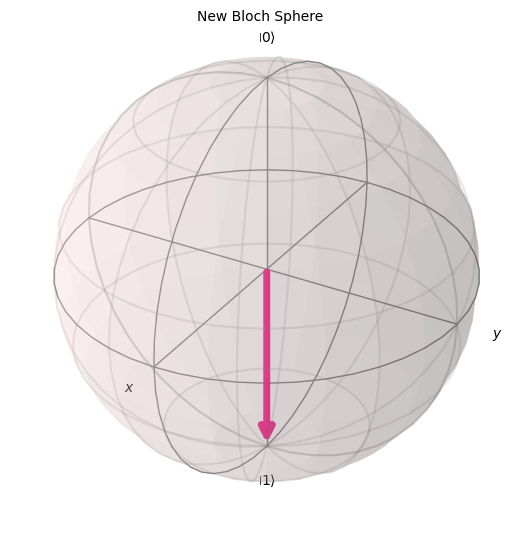

In [10]:
from qiskit.visualization import plot_bloch_vector
 
plot_bloch_vector([0,0,-1], title="New Bloch Sphere")